In [1]:
# --- セル1: ライブラリの準備 ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import MeCab
import ipadic
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 日本語フォント設定
plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False

print("ライブラリのインポート完了")

ライブラリのインポート完了


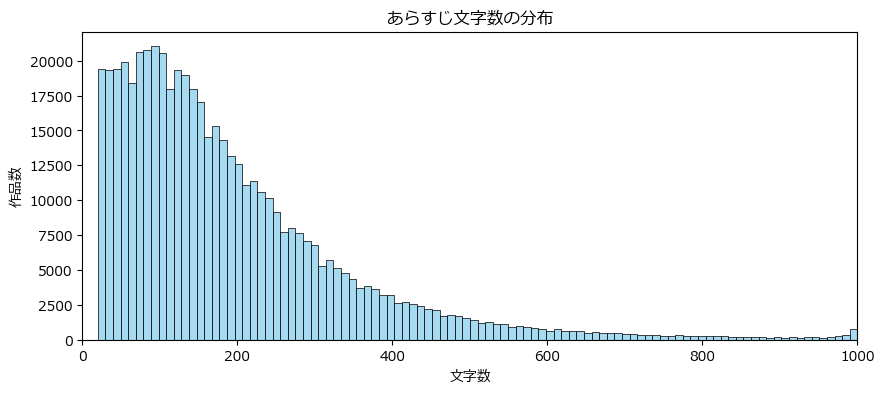

全データ数: 518775件
【しきい値の決定】
・Short群 :  20文字 〜 105文字
・Medium群: 106文字 〜 210文字
・Long群  : 211文字 〜


In [ ]:
# --- セル2: データ読み込みと分布確認 ---
csv_path = 'dataset/narou_dataset.csv'
df = pd.read_csv(csv_path)

# 欠損値処理と文字数カウント
df['あらすじ'] = df['あらすじ'].fillna('')
df['length'] = df['あらすじ'].str.len()

# 20文字未満はノイズとして除外（前回の知見より）
df = df[df['length'] >= 20].copy()

# --- 分布の確認 ---
plt.figure(figsize=(10, 4))
sns.histplot(df['length'], bins=100, color='skyblue')
plt.title('あらすじ文字数の分布')
plt.xlabel('文字数')
plt.ylabel('作品数')
plt.xlim(0, 1000) # 見やすくするため1000文字まで表示
plt.show()

# 3等分するためのしきい値（33%タイル点、66%タイル点）を算出
q33 = df['length'].quantile(0.333)
q66 = df['length'].quantile(0.666)

print(f"全データ数: {len(df)}件")
print(f"【閾値の決定】")
print(f"・Short群 :  20文字 〜 {int(q33)}文字")
print(f"・Medium群: {int(q33)+1}文字 〜 {int(q66)}文字")
print(f"・Long群  : {int(q66)+1}文字 〜")

In [3]:
# --- セル3: 文字数によるクラス分け ---

# データの分割
df_short  = df[df['length'] <= q33].copy()
df_medium = df[(df['length'] > q33) & (df['length'] <= q66)].copy()
df_long   = df[df['length'] > q66].copy()

# 各クラスのデータ数確認
print(f"Short群  : {len(df_short)}件")
print(f"Medium群 : {len(df_medium)}件")
print(f"Long群   : {len(df_long)}件")

# 後でループ処理しやすいように辞書にまとめる
datasets = {
    'Short': df_short,
    'Medium': df_medium,
    'Long': df_long
}

Short群  : 173403件
Medium群 : 172279件
Long群   : 173093件


In [4]:
# --- セル4: 前処理関数の定義 ---
chaser = MeCab.Tagger(ipadic.MECAB_ARGS)

def japanese_tokenizer(text):
    text = str(text)
    # URL除去
    text = re.sub(r'https?://[\w/:%#\$&\?\(\)~\.=\+\-]+', '<URL>', text)
    
    parsed = chaser.parse(text)
    words = []
    
    for line in parsed.split('\n'):
        if line == 'EOS' or line == '':
            continue
        parts = line.split('\t')
        word = parts[0]
        features = parts[1].split(',')
        
        # 名詞、動詞、形容詞、接頭詞を採用
        if features[0] in ['名詞', '動詞', '形容詞', '接頭詞']:
            # 不要なものを除外
            if features[1] in ['非自立', '代名詞', '数']:
                continue
            # 原形があれば使用
            if len(features) > 6 and features[6] != '*':
                words.append(features[6])
            else:
                words.append(word)
    return words

In [5]:
# --- セル5: 3クラスそれぞれの学習と分析 ---

# 結果格納用
results = {}

# 固定パラメータ
FIXED_MAX_FEATURES = 50000
FIXED_C = 1.0

print(f"分析開始 (次元数={FIXED_MAX_FEATURES}, C={FIXED_C})...")

for label, data in datasets.items():
    print(f"\n--- {label} ({len(data)}件) の分析 ---")
    
    # 1. アンダーサンプリング (エタる/完結の均衡化)
    df_eternal = data[data['is_eternal'] == 1]
    df_complete = data[data['is_eternal'] == 0]
    
    min_count = min(len(df_eternal), len(df_complete))
    
    # どちらかが極端に少ない場合はスキップ
    if min_count < 100:
        print(f"※データ不足のためスキップします (min_count={min_count})")
        continue

    df_balanced = pd.concat([
        df_eternal.sample(n=min_count, random_state=42),
        df_complete.sample(n=min_count, random_state=42)
    ]).sample(frac=1, random_state=42)
    
    X_text = df_balanced['あらすじ'].values
    y = df_balanced['is_eternal'].values
    
    # 2. 学習 (TF-IDF -> LogReg)
    vectorizer = TfidfVectorizer(
        tokenizer=japanese_tokenizer,
        max_features=FIXED_MAX_FEATURES,
        ngram_range=(1, 3),
        min_df=5
    )
    X_vec = vectorizer.fit_transform(X_text)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_vec, y, test_size=0.2, random_state=42, stratify=y
    )
    
    model = LogisticRegression(
        C=FIXED_C,
        solver='liblinear',
        class_weight='balanced',
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # 3. 精度確認
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"正解率: {acc:.4f}")
    
    # 4. 重要単語の抽出
    coefs = model.coef_[0]
    feature_names = vectorizer.get_feature_names_out()
    
    feat_df = pd.DataFrame({'word': feature_names, 'coef': coefs})
    
    # エタる単語(正の係数)と完結単語(負の係数)
    top_eternal = feat_df.sort_values(by='coef', ascending=False).head(10)
    top_complete = feat_df.sort_values(by='coef', ascending=True).head(10)
    
    # 結果を辞書に保存
    results[label] = {
        'accuracy': acc,
        'eternal_words': top_eternal,
        'complete_words': top_complete
    }

print("\n全クラスの分析完了。")

分析開始 (次元数=50000, C=1.0)...

--- Short (173403件) の分析 ---


c:\Users\blast\miniconda3\envs\torch311\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


正解率: 0.6535

--- Medium (172279件) の分析 ---


c:\Users\blast\miniconda3\envs\torch311\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


正解率: 0.6913

--- Long (173093件) の分析 ---


c:\Users\blast\miniconda3\envs\torch311\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


正解率: 0.6991

全クラスの分析完了。


C:\Users\blast\AppData\Local\Temp\ipykernel_6696\2390692850.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\blast\AppData\Local\Temp\ipykernel_6696\2390692850.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\blast\AppData\Local\Temp\ipykernel_6696\2390692850.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\blast\AppData\Local\Temp\ipykernel_6696\2390692850.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` 

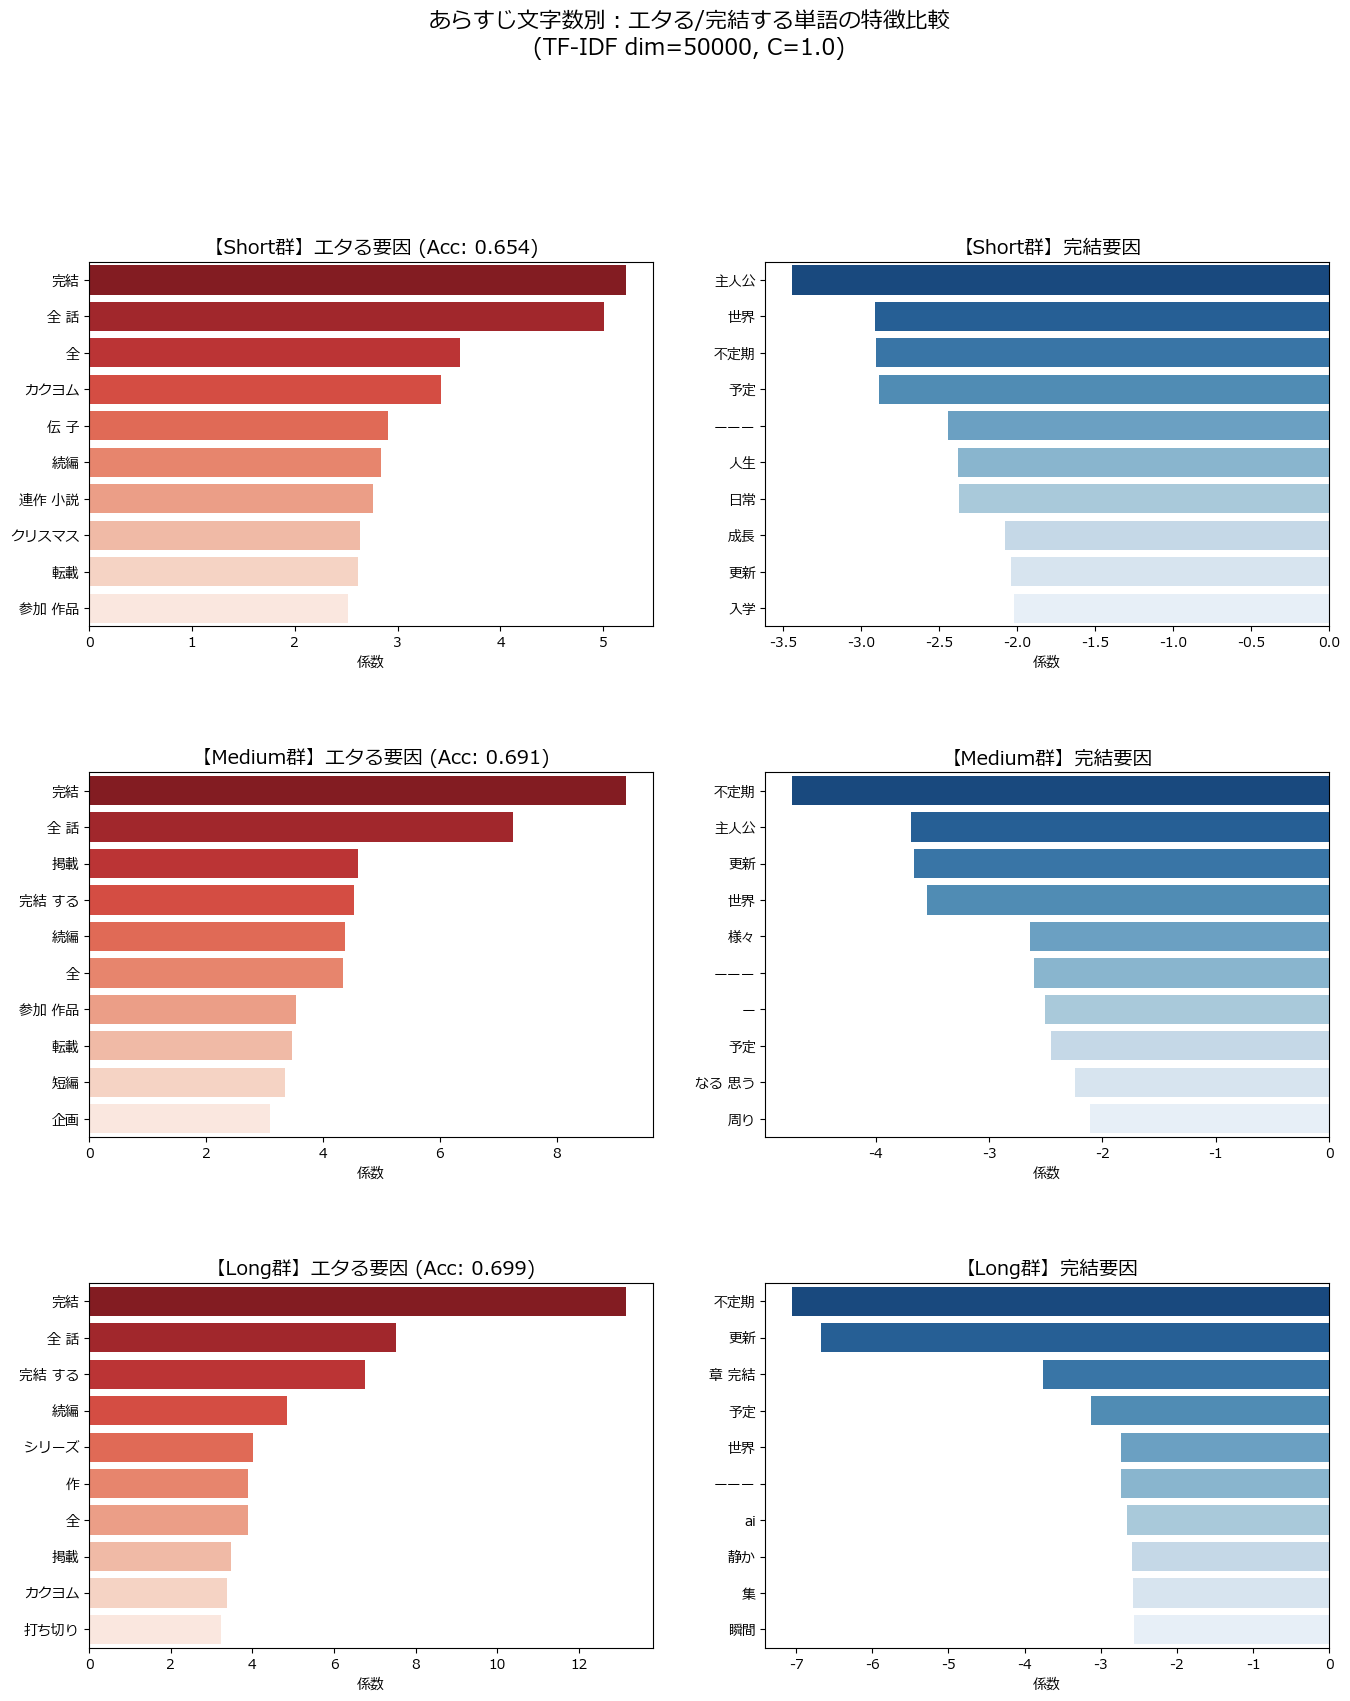

In [6]:
# --- セル6: クラス別 重要単語の比較可視化 ---

if not results:
    print("表示する結果がありません。")
else:
    # グラフの準備 (3行 x 2列)
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    plt.subplots_adjust(hspace=0.4)
    
    class_order = ['Short', 'Medium', 'Long']
    
    for i, label in enumerate(class_order):
        if label not in results:
            continue
            
        res = results[label]
        acc_score = res['accuracy']
        
        # エタる単語 (左列)
        sns.barplot(
            data=res['eternal_words'], 
            y='word', x='coef', 
            ax=axes[i, 0], palette='Reds_r'
        )
        axes[i, 0].set_title(f"【{label}群】エタる要因 (Acc: {acc_score:.3f})", fontsize=14)
        axes[i, 0].set_xlabel('係数')
        axes[i, 0].set_ylabel('')
        
        # 完結する単語 (右列)
        # 見やすくするため絶対値にして表示する手もありますが、ここではそのままマイナスで表示
        sns.barplot(
            data=res['complete_words'], 
            y='word', x='coef', 
            ax=axes[i, 1], palette='Blues_r'
        )
        axes[i, 1].set_title(f"【{label}群】完結要因", fontsize=14)
        axes[i, 1].set_xlabel('係数')
        axes[i, 1].set_ylabel('')

    plt.suptitle(f"あらすじ文字数別：エタる/完結する単語の特徴比較\n(TF-IDF dim={FIXED_MAX_FEATURES}, C={FIXED_C})", fontsize=16, y=1.02)
    plt.show()

In [7]:
# --- セル7: 結果の保存 ---
# ここでは簡易的にログをテキストとして保存します
import os
save_dir = 'result_length_analysis'
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, 'analysis_log.txt'), 'w', encoding='utf-8') as f:
    for label, res in results.items():
        f.write(f"=== {label} Group (Accuracy: {res['accuracy']:.4f}) ===\n")
        f.write("[エタる単語 Top10]\n")
        for idx, row in res['eternal_words'].iterrows():
            f.write(f"{row['word']}: {row['coef']:.4f}\n")
        f.write("\n[完結単語 Top10]\n")
        for idx, row in res['complete_words'].iterrows():
            f.write(f"{row['word']}: {row['coef']:.4f}\n")
        f.write("\n" + "-"*30 + "\n")

print(f"分析結果のログを {save_dir} に保存しました。")

分析結果のログを result_length_analysis に保存しました。
